# 03 — Detector configuration and exposure time

`setup_to_snr()` picks a detector configuration for you. Here we open the box: how the Lazuli
detector is read out, how this sets the exposure time and the noise, and how to set it yourself.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import slicersim

***
## 1. How an H4RG detector works

The Lazuli spectrograph detector is a Teledyne **H4RG**: a 4096×4096 HgCdTe array with 10 µm
pixels. Unlike a CCD, it is read **non-destructively**: the charge of each pixel is read
many times while it keeps accumulating, without being reset.

- A **frame** is one read of the full detector, every $t_\mathrm{frame}=2.83$ s.
- A **ramp** is the sequence of frames between two resets. The flux is the **slope** of the
  accumulated charge versus time. Fitting many reads beats down the readout noise and
  lets you detect cosmic-ray hits (jumps in the ramp).
- To limit the data volume, frames are averaged on board in **groups**. This is the
  **MACC(n, m, d)** mode: `n` groups of `m` averaged frames, with `d` frames dropped
  between groups.
- `nramps` identical ramps can be repeated.

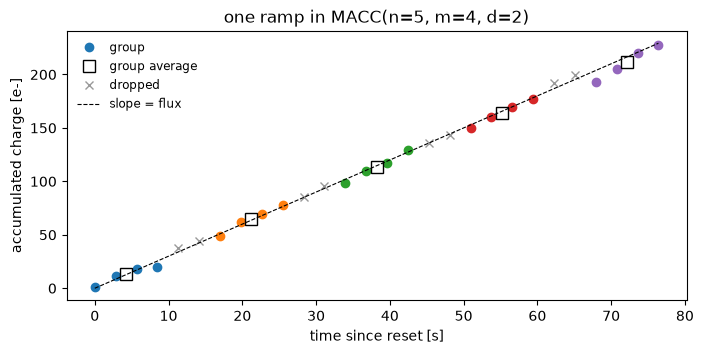

In [2]:
# illustration of a MACC(n=5, m=4, d=2) ramp
n, m, d, tframe = 5, 4, 2, 2.83
rng = np.random.default_rng(1)
t = np.arange(n * (m + d) - d) * tframe
charge = 3.0 * t + rng.normal(0, 4, size=t.size)   # flux * time + read noise

fig, ax = plt.subplots(figsize=(8, 3.5))
for i in range(n):
    sel = slice(i * (m + d), i * (m + d) + m)
    ax.plot(t[sel], charge[sel], "o", color=f"C{i}", label="group" if i == 0 else None)
    ax.plot(t[sel].mean(), charge[sel].mean(), "s", color="k", ms=8, mfc="none",
            label="group average" if i == 0 else None)
    if i < n - 1:
        drop = slice(i * (m + d) + m, (i + 1) * (m + d))
        ax.plot(t[drop], charge[drop], "x", color="0.6", label="dropped" if i == 0 else None)

ax.plot(t, 3.0 * t, "k--", lw=0.8, label="slope = flux")
ax.set(xlabel="time since reset [s]", ylabel="accumulated charge [e-]",
       title=f"one ramp in MACC(n={n}, m={m}, d={d})")
ax.legend(frameon=False, fontsize="small")

***
## 2. From detector configuration to exposure time

The timings follow from $(n, m, d)$, $t_\mathrm{frame}$ and `nramps`:

| quantity | formula |
|---|---|
| group time | $t_\mathrm{group} = (m+d)\,t_\mathrm{frame}$ |
| integration time (first→last group, sets the signal) | $t_\mathrm{int} = (n-1)\,t_\mathrm{group}$ |
| ramp duration | $t_\mathrm{ramp} = \left[n(m+d) - d\right]\,t_\mathrm{frame}$ |
| total exposure time | $t_\mathrm{tot} = n_\mathrm{ramps} \times t_\mathrm{ramp}$ |

Set the configuration by hand with `change_detector()`:

In [3]:
snia = slicersim.LazuliSupernova(redshift=1.0)
snia.change_detector(nmd=(32, 8, 0), nramps=2)

snia.get_readout_config()

{'nmd': (32, 8, 0), 'nramps': 2}

In [4]:
n, m, d = snia.get_properties("nmd")
nramps, tframe = snia.get_properties("nramps"), snia.get_properties("tframe")

print("by hand :", nramps * (n * (m + d) - d) * tframe, "s")
print("slicersim:", snia.get_exposure_time(full=True))

by hand : 1448.96 s
slicersim: {'integration_time': 701.84, 'exposure_time': 724.48, 'tframe': 2.83, 'tgroup': 22.64, 'total_exptime': 1448.96}


The data volume scales with the number of stored groups:

In [5]:
print(f"data volume: {snia.get_data_volume(units='GB'):.2f} GB")

data volume: 2.15 GB


***
## 3. Detector configuration and SNR

Fitting the ramp reduces the readout noise (RON) with the number of groups $n$ and of
averaged frames $m$ (Rauscher et al. 2007):

$$\sigma^2_\mathrm{RON,eff} = \frac{12\,(n-1)}{m\,n\,(n+1)}\;\sigma^2_\mathrm{RON}
\qquad (\sigma_\mathrm{RON}=12\ e^-\ \text{per frame})$$

while the signal grows with $t_\mathrm{int}$.

**Same exposure time (~24 min), different readouts:**

In [6]:
import pandas

snr_range = dict(lbda_range=[4000, 7000], frame="rest")
readouts = [((64, 8, 0), 1), ((16, 32, 0), 1), ((64, 4, 4), 1), ((64, 1, 7), 1),
            ((32, 8, 0), 2), ((8, 8, 0), 8)]

rows = []
for nmd, nramps in readouts:
    snia.change_detector(nmd=nmd, nramps=nramps)
    rows.append({"nmd": nmd, "nramps": nramps,
                 "exptime [s]": snia.get_exposure_time(),
                 "SNR": snia.get_band_snr(**snr_range),
                 "volume [GB]": snia.get_data_volume()})
pandas.DataFrame(rows).round(2)

,nmd,nramps,exptime [s],SNR,volume [GB]
0,"(64, 8, 0)",1,1448.96,6.32,2.15
1,"(16, 32, 0)",1,1448.96,6.31,0.54
2,"(64, 4, 4)",1,1437.64,5.72,2.15
3,"(64, 1, 7)",1,1429.15,3.96,2.15
4,"(32, 8, 0)",2,1448.96,4.90,2.15
5,"(8, 8, 0)",8,1448.96,1.63,2.15


- **Dropped frames are lost signal**: at fixed duration, `(64, 4, 4)` and `(64, 1, 7)` are worse.
- Trading groups for frames per group ($n \leftrightarrow m$, same $n\times m$) keeps the SNR
  but reduces the data volume. Many groups are nonetheless needed to detect cosmic-ray hits.
- **Splitting the time into several ramps is costly**: the RON is paid again on every ramp.

**SNR build-up with time:** a single ramp grows with $n$, then ramps are added.

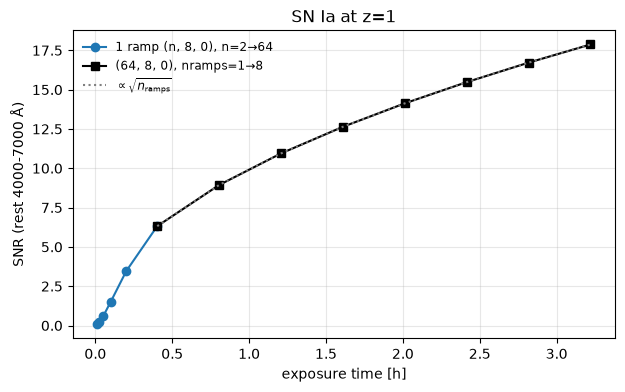

In [7]:
exptime, snr = [], []
for n in [2, 4, 8, 16, 32, 64]:
    snia.change_detector(nmd=(n, 8, 0), nramps=1)
    exptime.append(snia.get_exposure_time())
    snr.append(snia.get_band_snr(**snr_range))

exptime_r, snr_r = [], []
for nramps in range(1, 9):
    snia.change_detector(nmd=(64, 8, 0), nramps=nramps)
    exptime_r.append(snia.get_exposure_time())
    snr_r.append(snia.get_band_snr(**snr_range))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(np.asarray(exptime) / 3600, snr, "o-", label="1 ramp (n, 8, 0), n=2→64")
ax.plot(np.asarray(exptime_r) / 3600, snr_r, "s-", color="k", label="(64, 8, 0), nramps=1→8")
ax.plot(np.asarray(exptime_r) / 3600, snr_r[0] * np.sqrt(np.arange(1, 9)), ":", color="0.5",
        label=r"$\propto\sqrt{n_\mathrm{ramps}}$")
ax.set(xlabel="exposure time [h]", ylabel="SNR (rest 4000-7000 Å)", title="SN Ia at z=1")
ax.legend(frameon=False, fontsize="small")
ax.grid(alpha=0.3)

Ramps are limited to `max_group=64` groups (~24 min with $m=8$) because of cosmic rays,
saturation and data volume. Beyond that, the SNR grows as $\sqrt{n_\mathrm{ramps}}$.

***
## 4. What `setup_to_snr()` does

`setup_to_snr()` explores this grid for you:
1. it tests a single full ramp `(max_group, 8, 0)`;
2. if that is enough, it reduces `n` within a single ramp (using `m=4` or even `m=1` for bright
   targets);
3. otherwise, it adds ramps of `(max_group, 8, 0)`, then fine-tunes `n`.

With `inplace=False` it only returns the configuration, without changing the target:

In [8]:
snia = slicersim.LazuliSupernova(redshift=1.0)
config, snr = snia.setup_to_snr(10, inplace=False, **snr_range)
print("found  :", config, f"SNR={snr:.2f}")
print("target :", snia.get_readout_config(), "(unchanged)")

found  : {'nmd': (64, 8, 0), 'nramps': 2} SNR=8.94
target : {'nmd': [16, 8, 0], 'nramps': 1} (unchanged)


`setup_to_snr()` is just a shortcut: applying the same configuration by hand gives the same
result.

In [9]:
snia.change_detector(**config)
print(snia.get_readout_config(), f"SNR={snia.get_band_snr(**snr_range):.2f}",
      f"{snia.get_exposure_time()/3600:.2f} h")

{'nmd': (64, 8, 0), 'nramps': 2} SNR=8.94 0.80 h


The search is constrained by `max_group`. Limiting ramps to 20 groups (e.g. to mitigate cosmic
rays) forces more, shorter ramps, which costs time:

In [10]:
for max_group in [64, 20]:
    snia.change_detector(max_group=max_group)
    config, snr = snia.setup_to_snr(10, **snr_range)
    print(f"max_group={max_group}: {config}  ->  {snia.get_exposure_time()/3600:.2f} h")

max_group=64: {'nmd': (64, 8, 0), 'nramps': 2}  ->  0.80 h


max_group=20: {'nmd': (20, 8, 0), 'nramps': 28}  ->  3.52 h


***
## Recap

- The H4RG is read non-destructively; a ramp is sampled in MACC$(n, m, d)$ mode, repeated
  `nramps` times.
- `change_detector(nmd=..., nramps=..., max_group=...)` sets the configuration by hand;
  `get_readout_config()` reads it.
- The exposure time is entirely set by `nmd`, `nramps` and $t_\mathrm{frame}$.
- `setup_to_snr()` = search of the `(n, nramps)` grid + `change_detector()`.

**Next:** [04 — Changing properties on the fly](04_changing_properties.ipynb)